# Clustering

Trying multiple clustering approaches and visualizing the results using T-SNE. For finding the optimal number of clusters we choose Silhouette Method and Elbow Method where possible. 

## Imports

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist, pdist
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, pairwise_distances
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")
 
import utils

# Setup results

Validate Clustering Quality:
We compute the following **validation metrics** to assess the quality of clustering:
- **Davies-Bouldin Index** (lower is better)
- **Calinski-Harabasz Index** (higher is better)
- **Dunn Index** (higher is better)

In [2]:
results_df = pd.DataFrame(columns=[
    "Dataset",
    "Algorithm",
    "Davies-Bouldin Index",
    "Calinski-Harabasz Index",
    "Dunn Index"
])

# Default dataset

In [3]:
df = pd.read_csv("../Data/final_dataset.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   CountryCode                      89 non-null     object 
 1   CountryName                      89 non-null     object 
 2   TourismEmploymentPer1000         89 non-null     float64
 3   FoodEmploymentPer1000            69 non-null     float64
 4   TourismGDPPercentage             69 non-null     float64
 5   BusinessToPersonalRatio          76 non-null     float64
 6   AverageStayDays                  76 non-null     float64
 7   InboundArrivalsPer1000           83 non-null     float64
 8   DomesticTouristsPer1000          58 non-null     float64
 9   InboundToOutboundRatio           60 non-null     float64
 10  CostOfLivingIndex                85 non-null     float64
 11  GroceriesCostIndex               85 non-null     float64
 12  RestaurantPriceIndex    

In [5]:
df.isnull().sum()

CountryCode                         0
CountryName                         0
TourismEmploymentPer1000            0
FoodEmploymentPer1000              20
TourismGDPPercentage               20
BusinessToPersonalRatio            13
AverageStayDays                    13
InboundArrivalsPer1000              6
DomesticTouristsPer1000            31
InboundToOutboundRatio             29
CostOfLivingIndex                   4
GroceriesCostIndex                  4
RestaurantPriceIndex                4
SafetyIndex                         1
HealthCareIndex                    23
PollutionIndex                     15
QualityOfLifeIndex                 27
ClimateIndex                       27
TrafficIndex                       26
TrafficTimeIndexMinutes            26
TrafficInefficiencyIndex           26
ReverseTrafficInefficiencyIndex    26
ReverseTrafficTimeIndexMinutes     26
ReverseTrafficIndex                26
ReversePollutionIndex              15
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TourismEmploymentPer1000,89.0,25.639881,30.208117,0.864344,7.796310,19.709909,32.664306,197.352016
FoodEmploymentPer1000,69.0,12.246579,11.200774,0.182560,4.457795,9.858471,16.525622,54.312951
TourismGDPPercentage,69.0,3.578292,2.414450,0.061836,1.890788,3.104375,4.807650,11.728354
BusinessToPersonalRatio,76.0,0.243344,0.302023,0.009091,0.075744,0.129049,0.294344,1.764563
AverageStayDays,76.0,4.094567,3.644277,1.330224,2.027468,2.596871,4.368941,22.250457
InboundArrivalsPer1000,83.0,467.887608,810.467671,0.933245,41.244642,152.022395,579.640235,5825.335690
DomesticTouristsPer1000,58.0,1242.807826,1063.717487,0.153039,470.210368,1067.305597,1682.990724,5157.844808
InboundToOutboundRatio,60.0,2.337931,2.771569,0.197945,0.633283,1.470492,2.730327,15.654869
CostOfLivingIndex,85.0,41.295294,14.694038,19.000000,30.400000,38.800000,49.400000,98.400000
GroceriesCostIndex,85.0,43.062353,15.575301,19.700000,33.200000,40.100000,54.500000,103.100000


In [7]:
all_numerical_features_df = df.copy()
all_numerical_features_df.drop(columns=["CountryName","CountryCode", "TrafficIndex", "TrafficTimeIndexMinutes","TrafficInefficiencyIndex", "PollutionIndex"], inplace=True)

## Imputation

In [8]:
from fancyimpute import IterativeImputer

imputer = IterativeImputer(max_iter=100, random_state=0)

imputed_data = imputer.fit_transform(all_numerical_features_df)

imputed_df = pd.DataFrame(imputed_data, columns=all_numerical_features_df.columns)

print(imputed_df.head())

   TourismEmploymentPer1000  FoodEmploymentPer1000  TourismGDPPercentage  \
0                 15.608840               2.976254              6.475350   
1                  7.411779               3.596785              1.129921   
2                  2.439200               0.710283              3.075387   
3                 28.270541              11.444930              1.890788   
4                 21.464763               7.825559              1.572674   

   BusinessToPersonalRatio  AverageStayDays  InboundArrivalsPer1000  \
0                 0.021680         2.562741             1793.802738   
1                 1.764563         1.621484             -362.819954   
2                 0.111823         4.000000                2.001969   
3                 0.140625         2.552286               16.460292   
4                 0.280377         2.216665              247.324185   

   DomesticTouristsPer1000  InboundToOutboundRatio  CostOfLivingIndex  \
0               433.307621                6

In [9]:
imputed_df.isnull().sum()

TourismEmploymentPer1000           0
FoodEmploymentPer1000              0
TourismGDPPercentage               0
BusinessToPersonalRatio            0
AverageStayDays                    0
InboundArrivalsPer1000             0
DomesticTouristsPer1000            0
InboundToOutboundRatio             0
CostOfLivingIndex                  0
GroceriesCostIndex                 0
RestaurantPriceIndex               0
SafetyIndex                        0
HealthCareIndex                    0
QualityOfLifeIndex                 0
ClimateIndex                       0
ReverseTrafficInefficiencyIndex    0
ReverseTrafficTimeIndexMinutes     0
ReverseTrafficIndex                0
ReversePollutionIndex              0
dtype: int64

## Standardization

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data=scaler.fit_transform(imputed_df)
scaled_df = pd.DataFrame(scaled_data, columns=imputed_df.columns)

default_dataset = pd.concat([df[["CountryName", "CountryCode"]], scaled_df] , axis=1)

In [11]:
default_dataset.head()

,CountryName,CountryCode,TourismEmploymentPer1000,FoodEmploymentPer1000,TourismGDPPercentage,BusinessToPersonalRatio,AverageStayDays,InboundArrivalsPer1000,DomesticTouristsPer1000,InboundToOutboundRatio,...,GroceriesCostIndex,RestaurantPriceIndex,SafetyIndex,HealthCareIndex,QualityOfLifeIndex,ClimateIndex,ReverseTrafficInefficiencyIndex,ReverseTrafficTimeIndexMinutes,ReverseTrafficIndex,ReversePollutionIndex
0,Albania,ALB,-0.333946,-0.714085,1.134190,-0.784470,-0.439641,1.703132,-0.758633,1.396466,...,-0.180088,-0.110648,-0.116997,-1.826395,-0.906599,0.577393,1.116766,0.012744,0.748638,-1.121363
1,Algeria,DZA,-0.606836,-0.661768,-1.036999,5.481502,-0.716900,-0.939417,-0.297964,-0.647739,...,-0.652671,-1.414824,-0.688126,-1.124258,-0.751506,-0.029770,-0.153850,-0.457228,-0.270525,-0.465680
2,Angola,AGO,-0.772379,-0.905131,-0.246796,-0.460390,-0.016278,-0.492394,-0.697194,1.342382,...,-0.662604,-0.830074,-1.678564,-0.588494,-1.157851,-0.025540,-0.971425,-1.131093,-1.124401,-0.795596
3,Argentina,ARG,0.087578,-0.000084,-0.727953,-0.356842,-0.442720,-0.474678,-0.523754,-0.655789,...,-0.403252,-0.022602,-1.468909,0.380322,-0.541610,1.551606,-0.130483,-0.800197,-0.434064,0.190003
4,Australia,AUS,-0.138995,-0.305236,-0.857163,0.145592,-0.541582,-0.191796,2.258662,-0.440609,...,1.624917,1.044951,-0.304964,0.982154,1.435188,1.183206,-0.817055,-0.067405,-0.192457,1.391254


## Algorithms

### DBScan

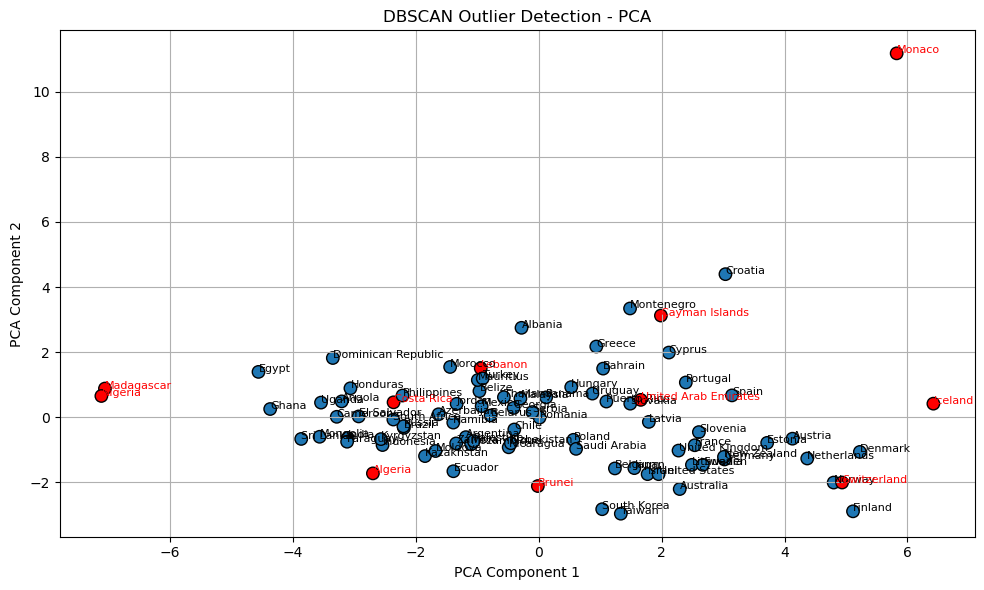

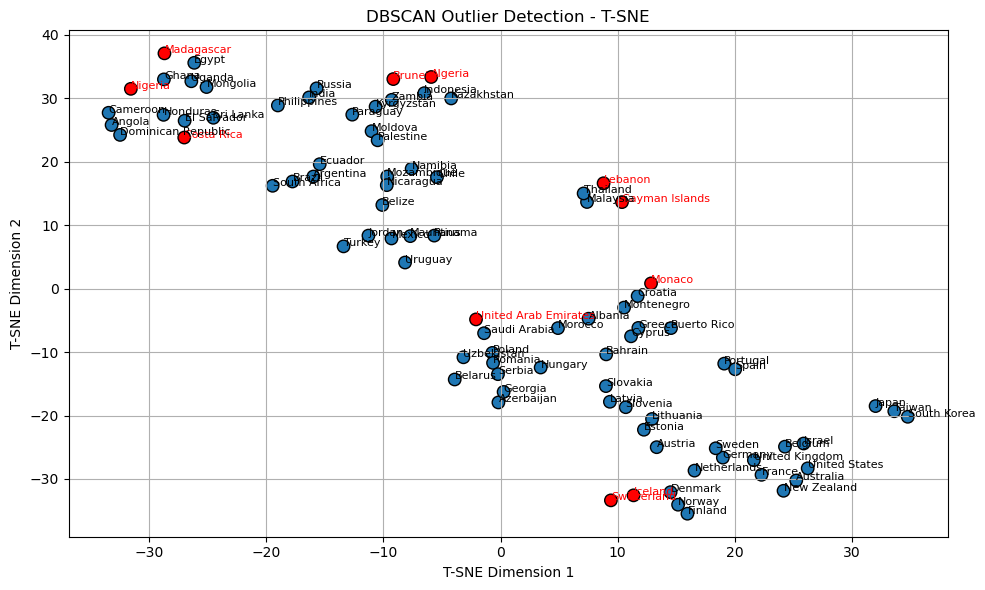


Outlier Countries Detected:
             CountryName CountryCode
1                Algeria         DZA
12                Brunei         BRN
14        Cayman Islands         CYM
16            Costa Rica         CRI
33               Iceland         ISL
42               Lebanon         LBN
44            Madagascar         MDG
49                Monaco         MCO
58               Nigeria         NGA
78           Switzerland         CHE
83  United Arab Emirates         ARE


In [12]:
outliers = utils.detect_dbscan_outliers(default_dataset)

### K-Means

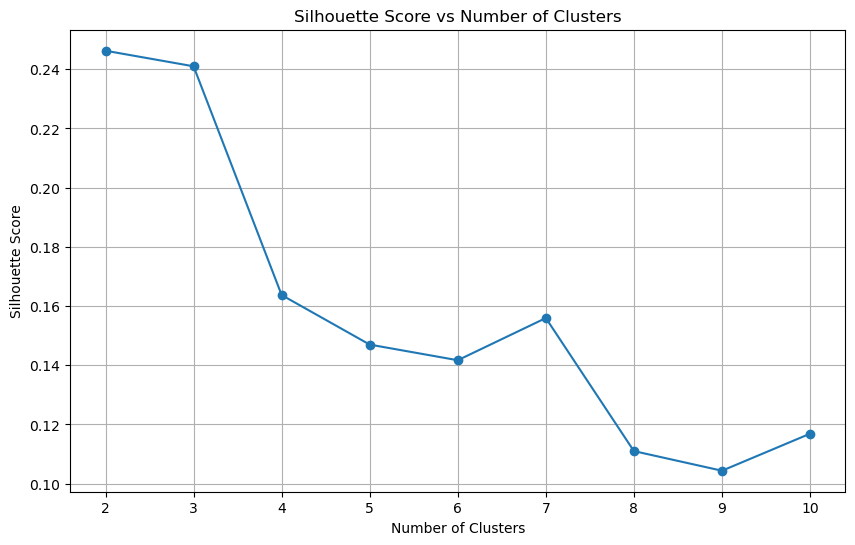

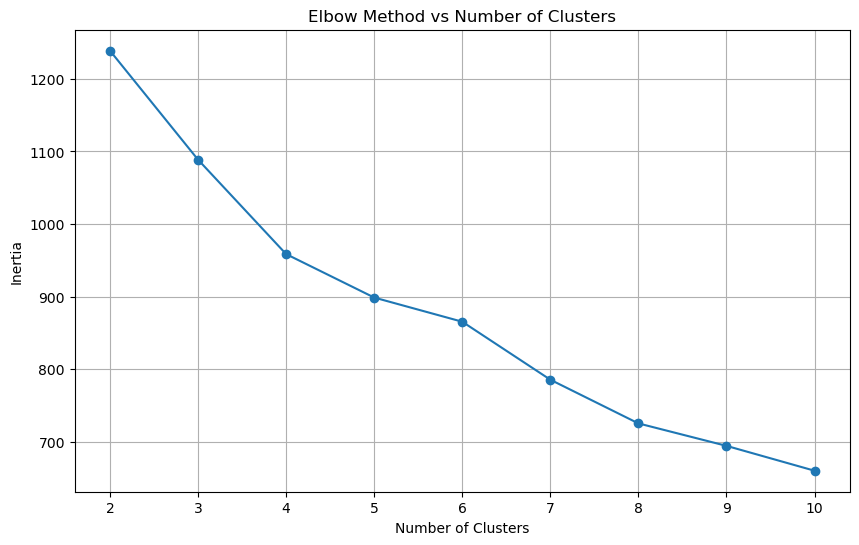

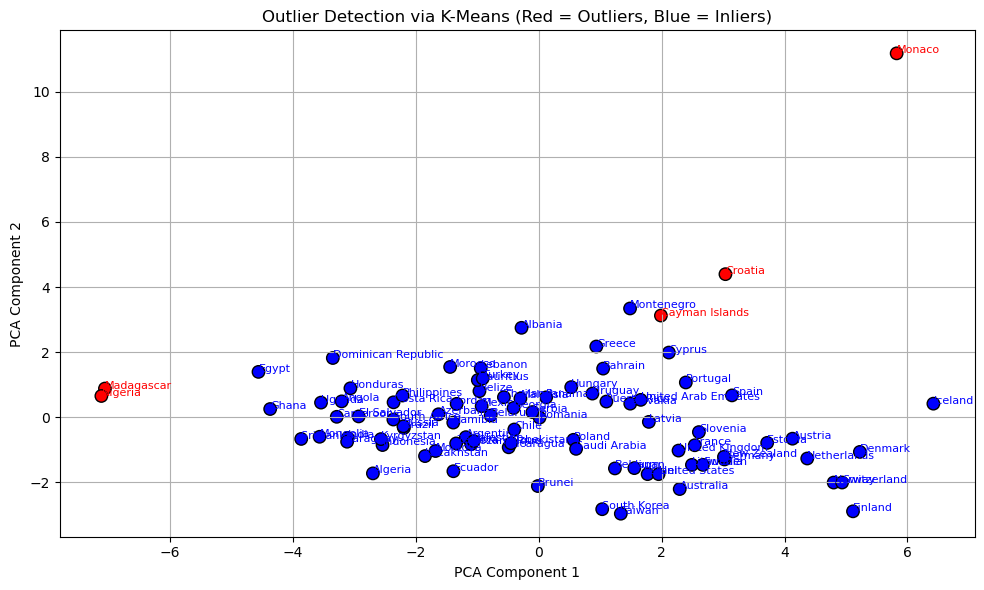

Outlier Countries:
['Cayman Islands', 'Croatia', 'Madagascar', 'Monaco', 'Nigeria']

Validation Indices:
Davies-Bouldin Index: 1.514414770301175
Calinski-Harabasz Index: 31.893141955788348
Dunn Index: 0.0784326061480343


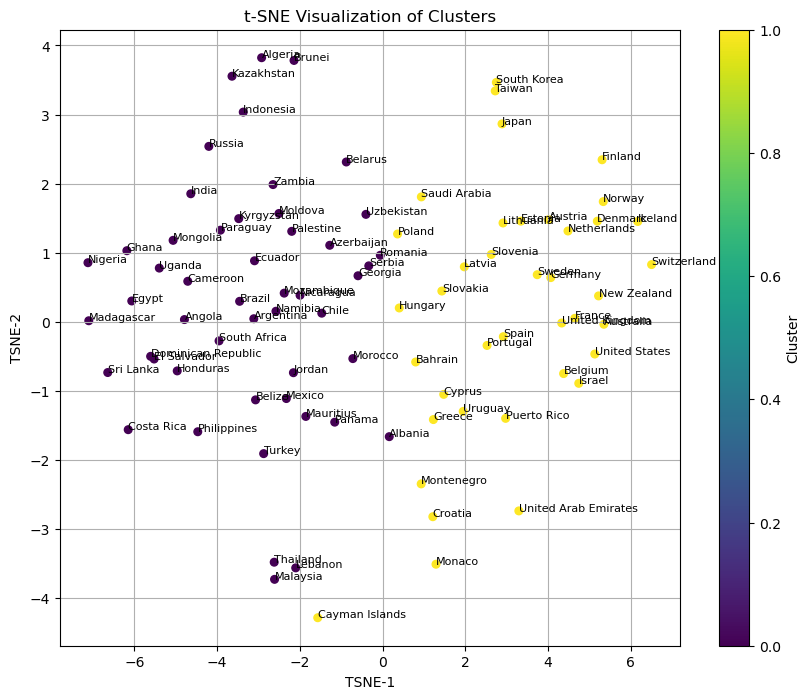

In [13]:
default_dataset_copy = default_dataset.copy()
numerical_features_df_default = default_dataset_copy.drop(columns=['CountryCode', 'CountryName'])

outliers_df,cluster_labels,kmeans_indices = utils.detect_kmeans_outliers(default_dataset_copy)
utils.applyTSNE(numerical_features_df_default, cluster_labels)

In [14]:
# K-means results
kmeans_row = pd.DataFrame([{
    "Dataset": "Baseline Dataset",
    "Algorithm": "K-means",
    "Davies-Bouldin Index": kmeans_indices["Davies-Bouldin Index"],
    "Calinski-Harabasz Index": kmeans_indices["Calinski-Harabasz Index"],
    "Dunn Index": kmeans_indices["Dunn Index"]
}])

# Append K-means row
results_df = pd.concat([results_df, kmeans_row], ignore_index=True)

results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433


### Hierarchical clustering

### 1: Evaluate Cluster Quality for Different `k`
We start by evaluating different choices for the number of clusters (`k`) using two methods:
- **Silhouette Score**: Measures how similar each point is to its own cluster vs. other clusters.
- **Elbow Method (KMeans Inertia)**: Measures the within-cluster sum of squares. We look for a point ("elbow") where adding more clusters yields diminishing returns.

These plots guide the selection of an appropriate `k`.

### 2: Visualize Cluster Structure via Dendrograms
We generate multiple **dendrograms** (tree diagrams) to visually assess how the data naturally clusters. This helps validate our `k` choice and provides interpretability into the hierarchy of merges.

In [15]:
default_dataset_copy = default_dataset.copy()
numerical_features_df_default = default_dataset_copy.drop(columns=['CountryCode', 'CountryName'])
labels_df = default_dataset_copy[['CountryCode', 'CountryName']]

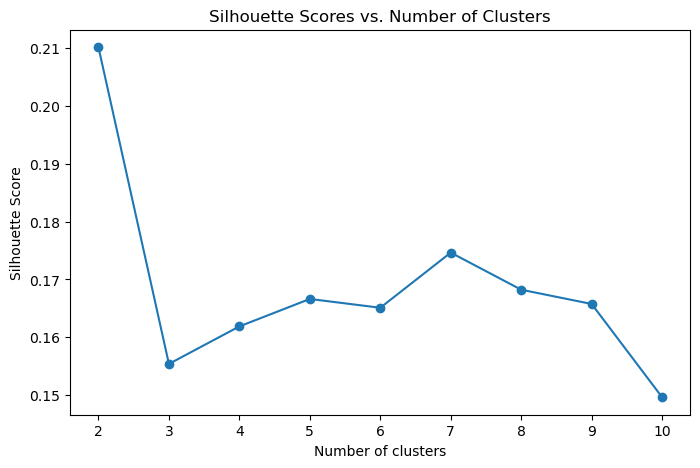

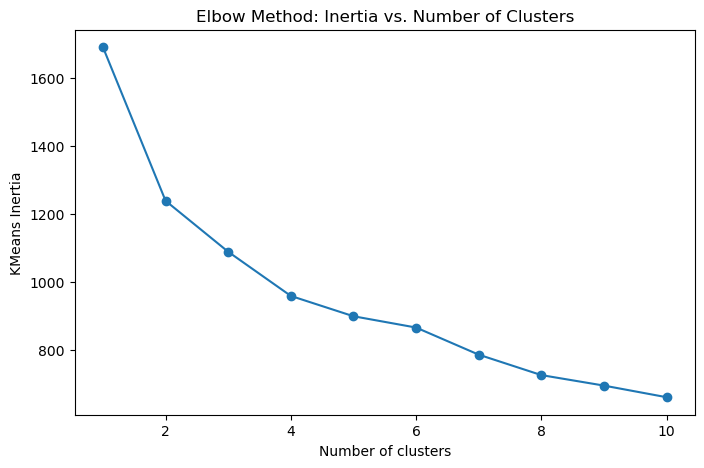

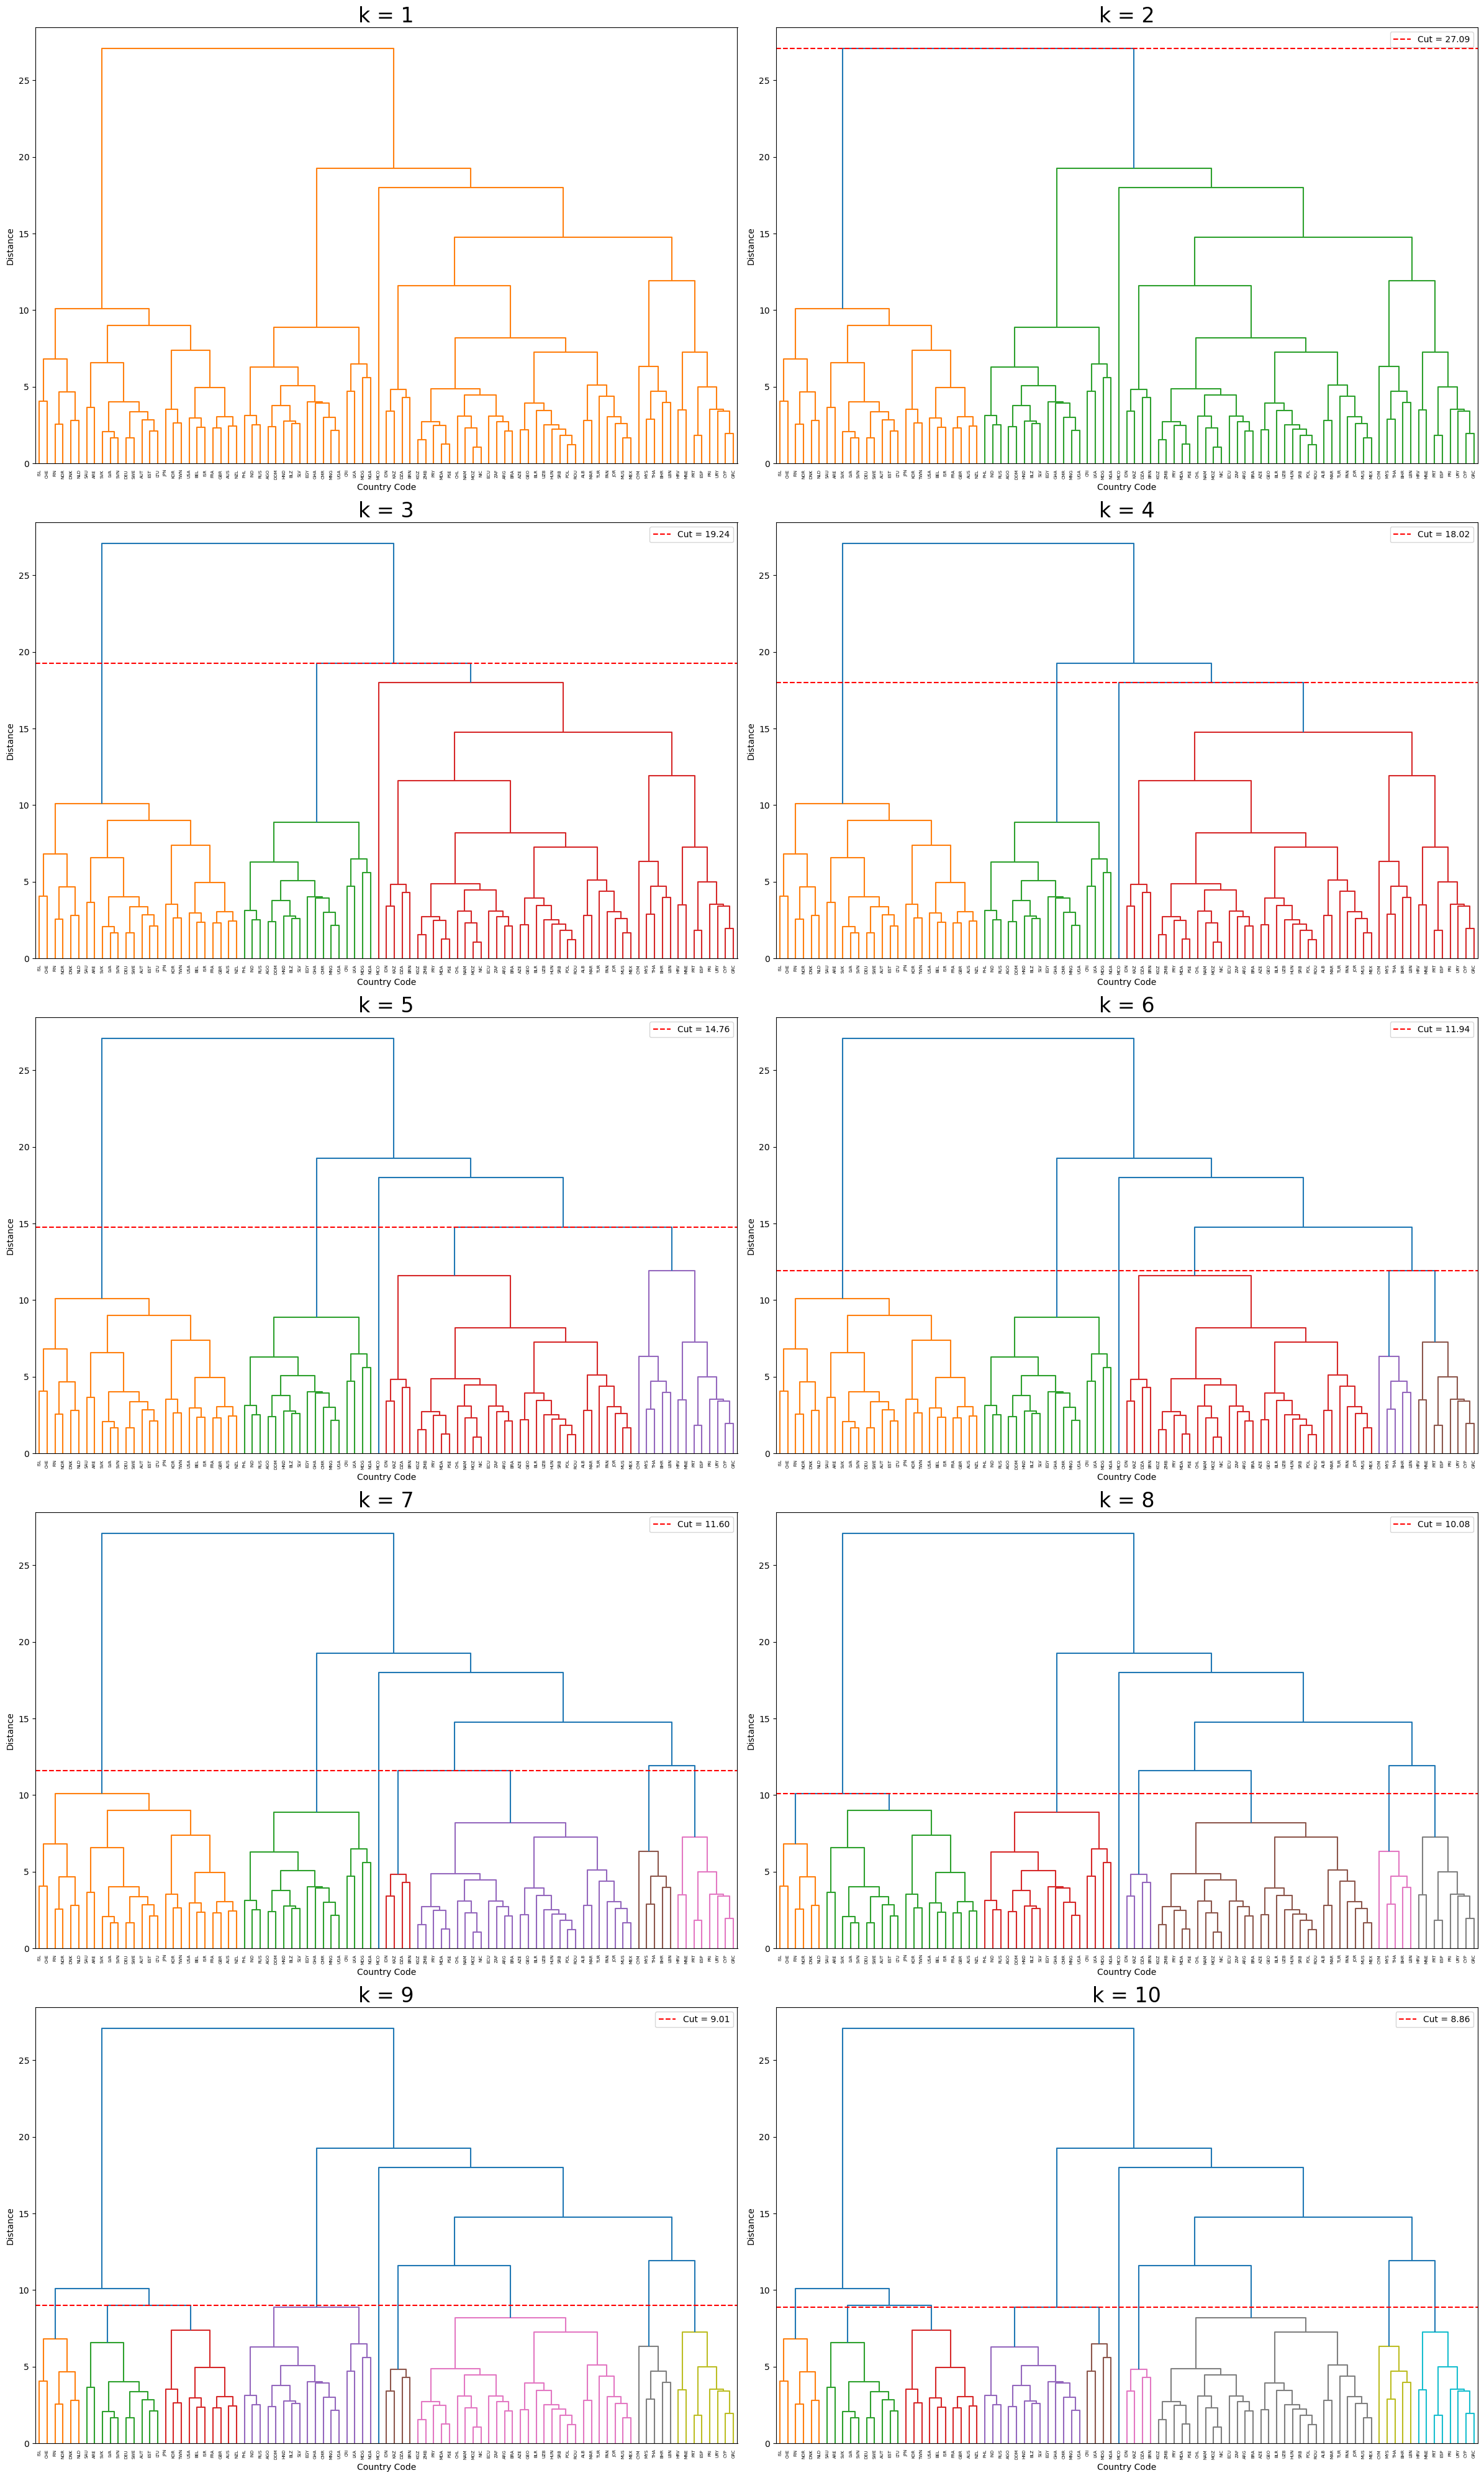

In [16]:
# Plot Silhouette and Elbow methods to aid in choosing the number of clusters
silhouette_scores = utils.plot_silhouette_scores(numerical_features_df_default, k_range=range(2, 11))
inertias = utils.plot_elbow_method(numerical_features_df_default, k_range=range(1, 11))

# Plot multiple dendrograms for k = 1 to 10 to visually compare cluster separations
utils.plot_multiple_dendrograms(numerical_features_df_default, countries=labels_df, max_k=10)

### 3: Perform Agglomerative Clustering
Using the selected number of clusters, we run the full hierarchical clustering pipeline:
- Optionally apply PCA (used to visualize in comparison with t-SNE, not used for final results).
- Fit an Agglomerative Clustering model.
- Attach cluster labels to countries and features.
- Visualize results in:
  - A full dendrogram for the chosen `k`
  - A **t-SNE scatter plot** colored by cluster, overlaid with country names for interpretability.

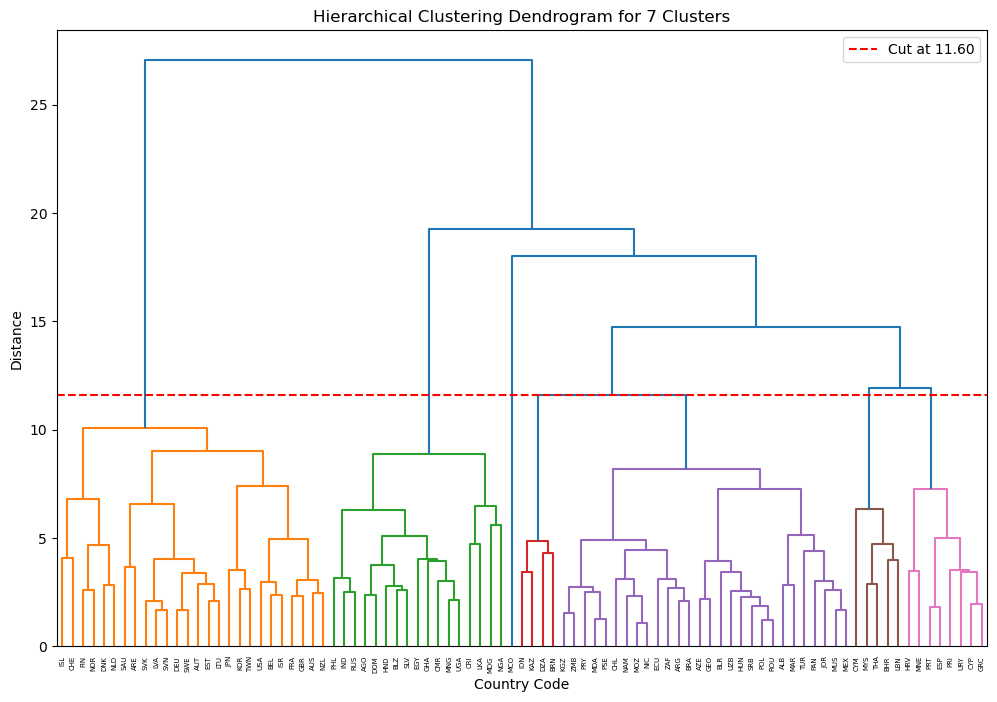

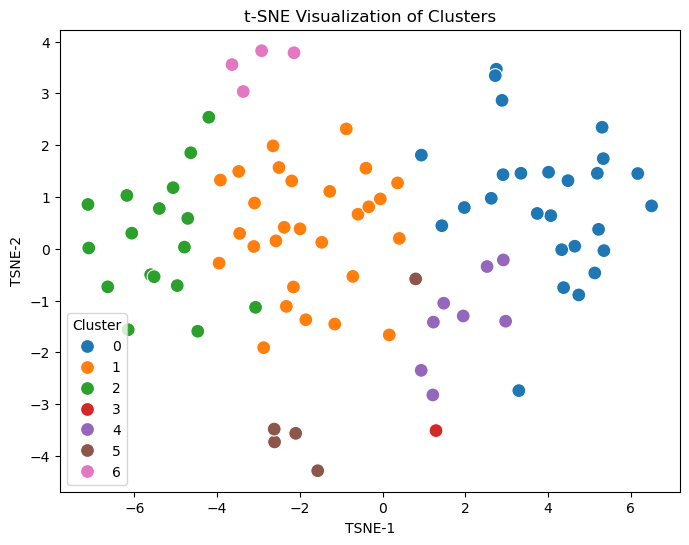

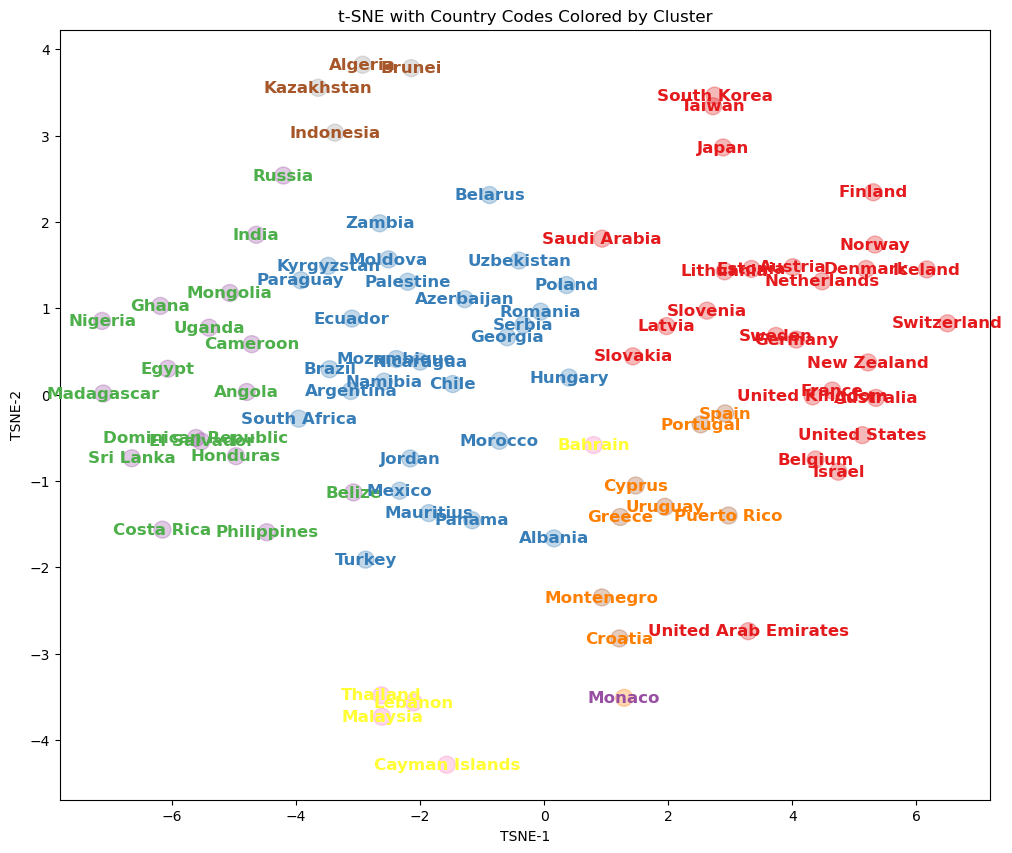

Validation Indices:
Davies-Bouldin Index: 1.2458759294397501
Calinski-Harabasz Index: 18.026237172211303
Dunn Index: 0.2504850511409487
Cluster mapping:
Cluster 0: Australia, Austria, Belgium, Denmark, Estonia, Finland, France, Germany, Iceland, Israel, Japan, Latvia, Lithuania, Netherlands, New Zealand, Norway, Saudi Arabia, Slovakia, Slovenia, South Korea, Sweden, Switzerland, Taiwan, United Arab Emirates, United Kingdom, United States
Cluster 1: Albania, Argentina, Azerbaijan, Belarus, Brazil, Chile, Ecuador, Georgia, Hungary, Jordan, Kyrgyzstan, Mauritius, Mexico, Moldova, Morocco, Mozambique, Namibia, Nicaragua, Palestine, Panama, Paraguay, Poland, Romania, Serbia, South Africa, Turkey, Uzbekistan, Zambia
Cluster 2: Angola, Belize, Cameroon, Costa Rica, Dominican Republic, Egypt, El Salvador, Ghana, Honduras, India, Madagascar, Mongolia, Nigeria, Philippines, Russia, Sri Lanka, Uganda
Cluster 3: Monaco
Cluster 4: Croatia, Cyprus, Greece, Montenegro, Portugal, Puerto Rico, Spain, U

In [17]:
k_opt = 7
# Perform hierarchical clustering on the selected features using a chosen k
df_combined, cluster_labels, hierarchical_indices = utils.run_clustering_analysis(
    numerical_features_df_default,
    countries=labels_df,
    k_clusters=k_opt,
    plot_dendrogram_flag=True,
    plot_tsne_flag=True,
    compute_validation=True
)

### Output
The final result is a `DataFrame` containing:
- Country information (CountryCode, CountryName)
- All features used in clustering
- Cluster assignments
- t-SNE coordinates for visualization

In [18]:
# Hierarchical Clustering results
hierarchical_row = pd.DataFrame([{
    "Dataset": "Baseline Dataset",
    "Algorithm": "Hierarchical Clustering",
    "Davies-Bouldin Index": hierarchical_indices["Davies-Bouldin Index"],
    "Calinski-Harabasz Index": hierarchical_indices["Calinski-Harabasz Index"],
    "Dunn Index": hierarchical_indices["Dunn Index"]
}])

# Append Hierarchical Clustering row
results_df = pd.concat([results_df, hierarchical_row], ignore_index=True)

results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433
1,Baseline Dataset,Hierarchical Clustering,1.245876,18.026237,0.250485


# Overall Correlation Analysis

# Feature selection dataset

In [19]:
feature_selection_df = pd.read_csv("../Data/final_cleaned_dataset.csv", index_col=0)

labels_df = feature_selection_df[['CountryCode', 'CountryName']]
numerical_features_feature_selection_df = feature_selection_df.drop(columns=['CountryCode', 'CountryName'])

## Algorithms

### DBScan

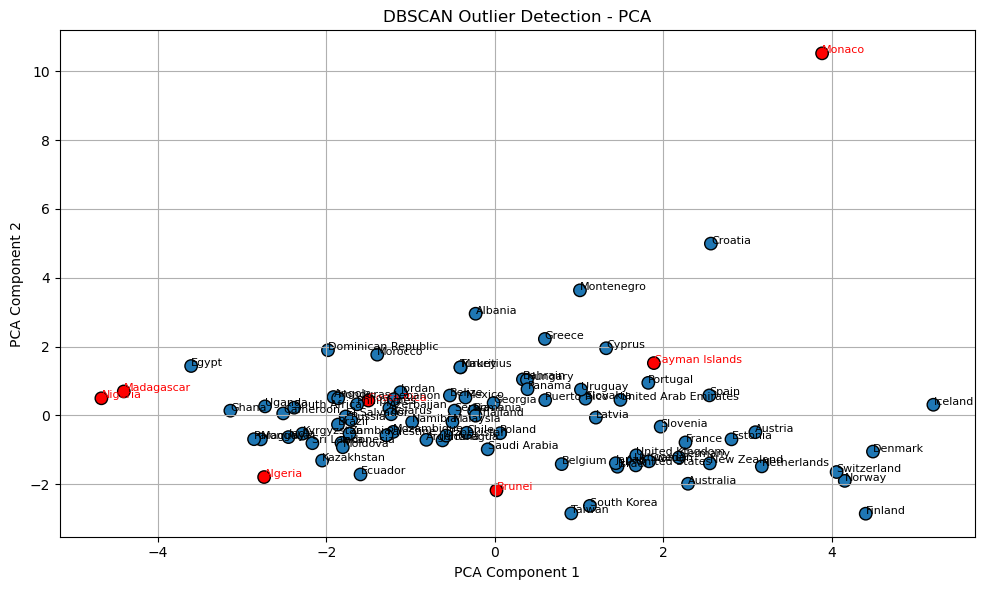

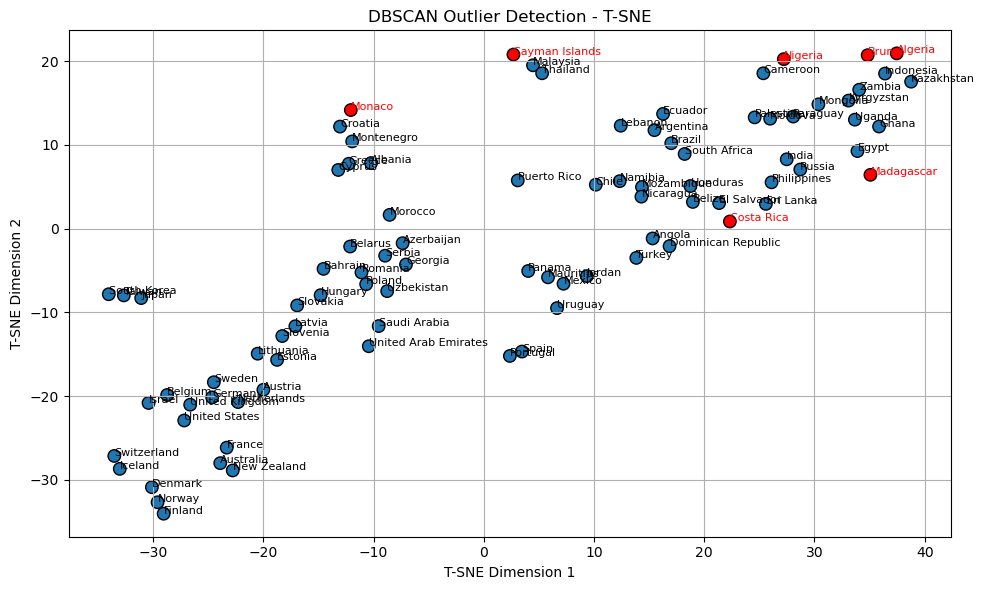


Outlier Countries Detected:
       CountryName CountryCode
1          Algeria         DZA
12          Brunei         BRN
14  Cayman Islands         CYM
16      Costa Rica         CRI
44      Madagascar         MDG
49          Monaco         MCO
58         Nigeria         NGA


In [20]:
outliers = utils.detect_dbscan_outliers(feature_selection_df)

### K-Means

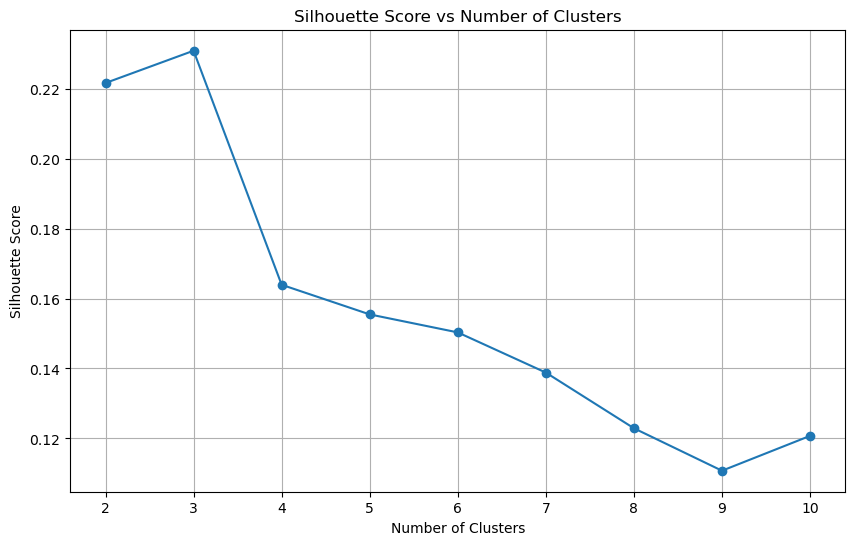

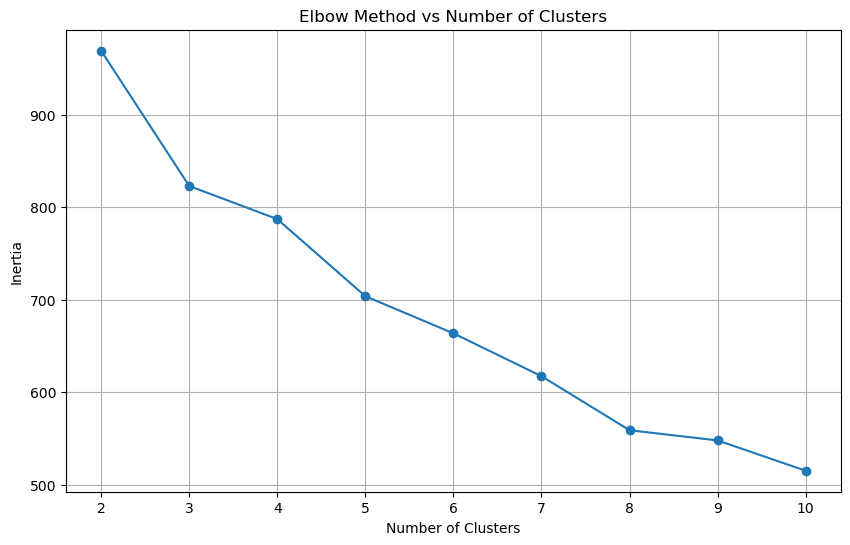

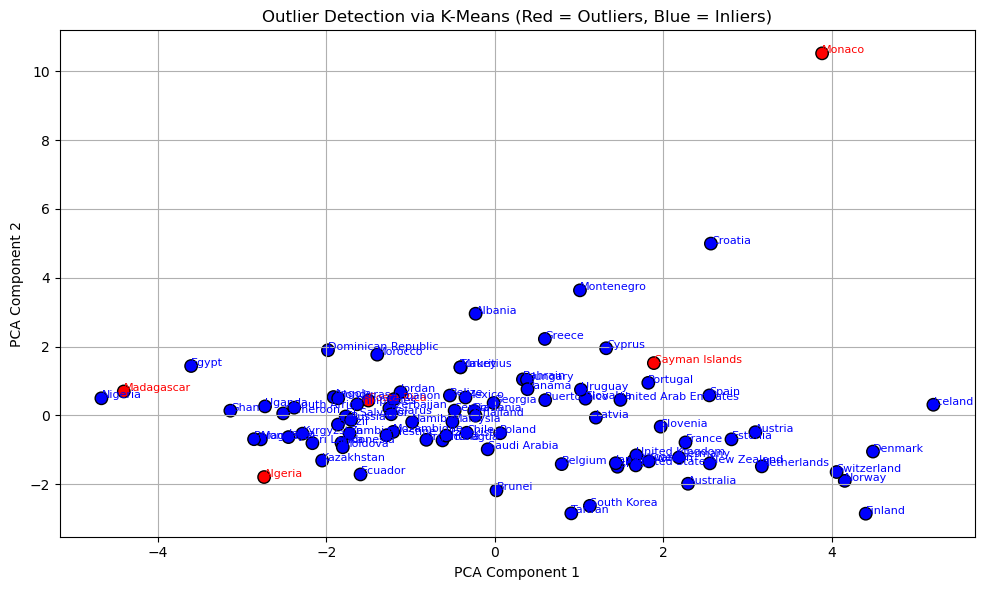

Outlier Countries:
['Algeria', 'Cayman Islands', 'Costa Rica', 'Madagascar', 'Monaco']

Validation Indices:
Davies-Bouldin Index: 1.3360150613618538
Calinski-Harabasz Index: 22.10964978203554
Dunn Index: 0.17835221819148034


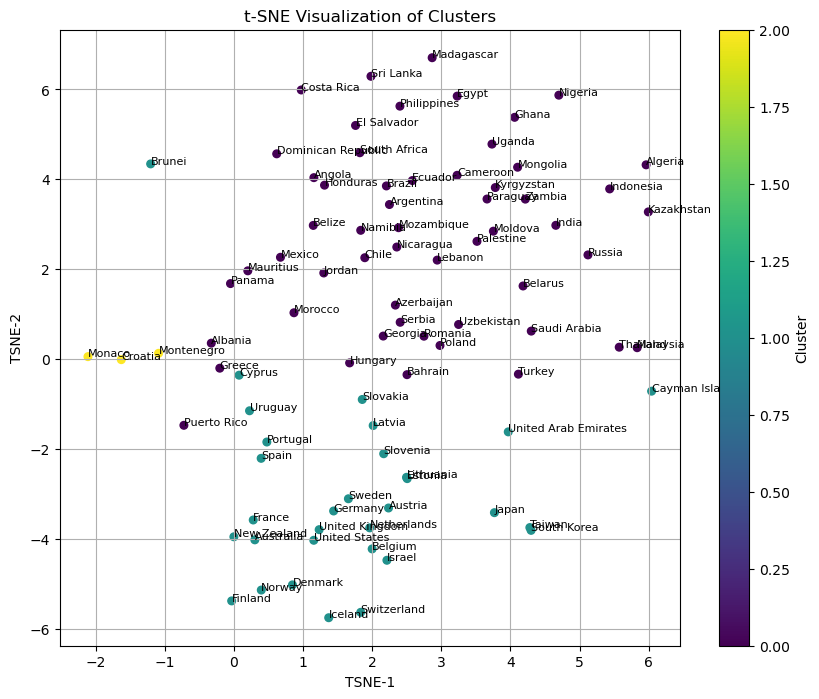

In [21]:
feature_selection_df_copy = feature_selection_df.copy()
numerical_features_feature_selection_df = feature_selection_df_copy.drop(columns=['CountryCode', 'CountryName'])

outliers_df,cluster_labels,kmeans_indices = utils.detect_kmeans_outliers(feature_selection_df_copy)
utils.applyTSNE(numerical_features_feature_selection_df, cluster_labels)

In [22]:
# K-means results
kmeans_row = pd.DataFrame([{
    "Dataset": "Optimized Dataset",
    "Algorithm": "K-means",
    "Davies-Bouldin Index": kmeans_indices["Davies-Bouldin Index"],
    "Calinski-Harabasz Index": kmeans_indices["Calinski-Harabasz Index"],
    "Dunn Index": kmeans_indices["Dunn Index"]
}])

# Append K-means row
results_df = pd.concat([results_df, kmeans_row], ignore_index=True)

results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433
1,Baseline Dataset,Hierarchical Clustering,1.245876,18.026237,0.250485
2,Optimized Dataset,K-means,1.336015,22.109650,0.178352


### Hierarchical clustering

In [23]:
feature_selection_df_copy = feature_selection_df.copy()
numerical_features_feature_selection_df = feature_selection_df_copy.drop(columns=['CountryCode', 'CountryName'])
labels_df = feature_selection_df_copy[['CountryCode', 'CountryName']]

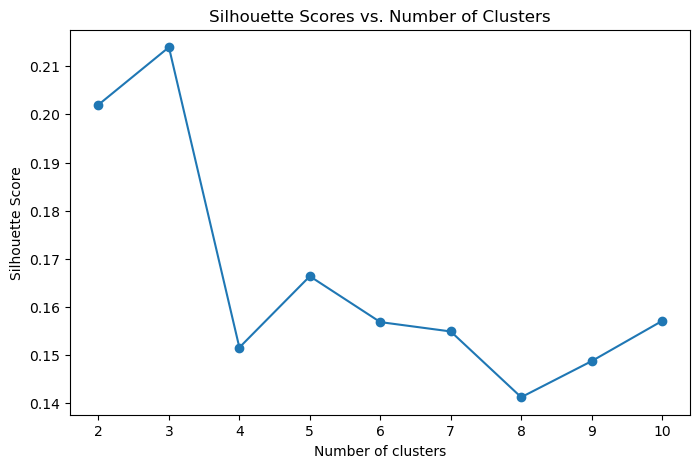

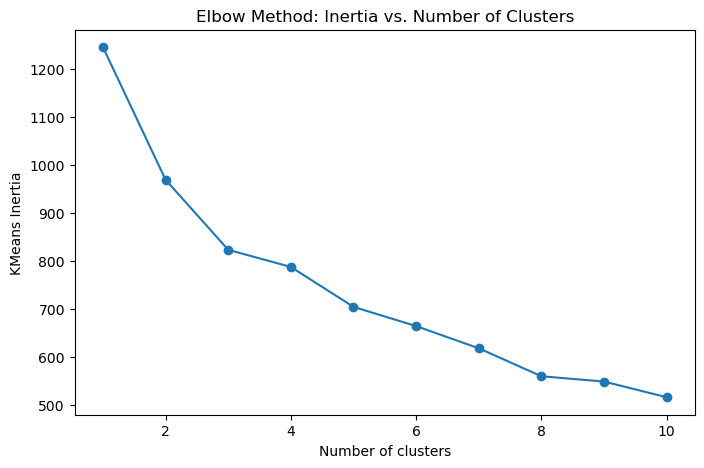

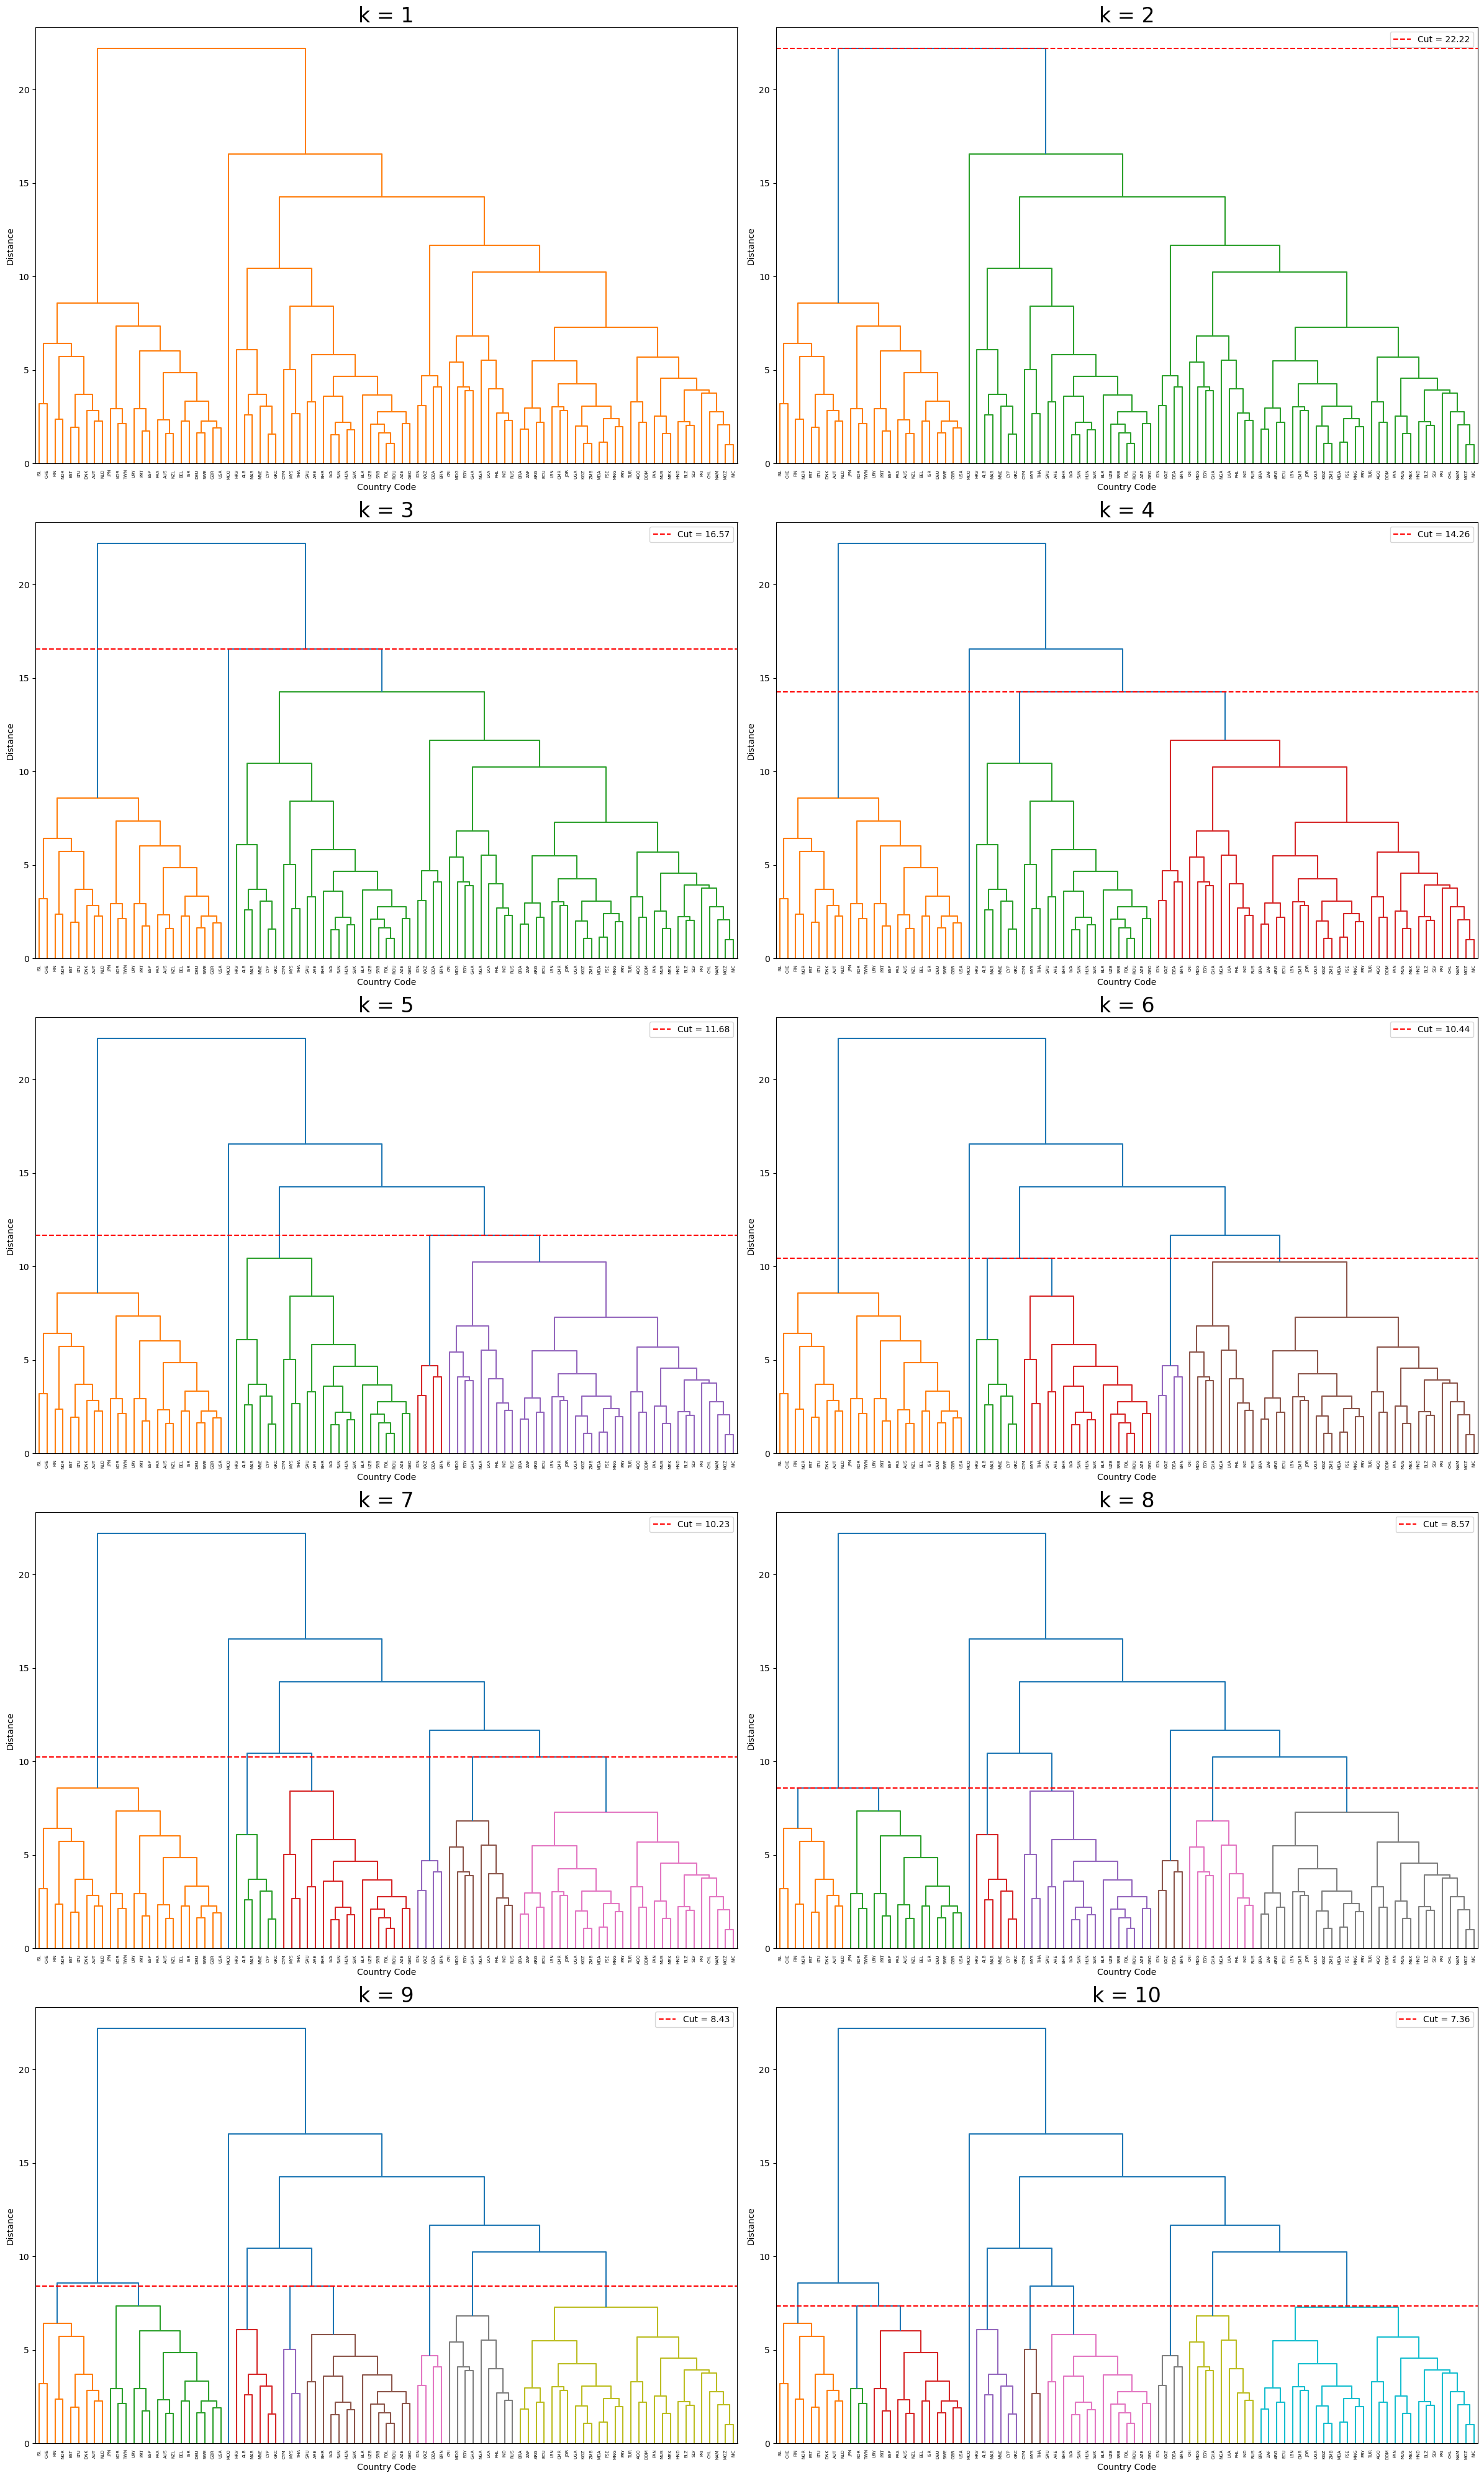

In [24]:
# Plot Silhouette and Elbow methods to aid in choosing the number of clusters
silhouette_scores = utils.plot_silhouette_scores(numerical_features_feature_selection_df, k_range=range(2, 11))
inertias = utils.plot_elbow_method(numerical_features_feature_selection_df, k_range=range(1, 11))

# Plot multiple dendrograms for k = 1 to 10 to visually compare cluster separations
utils.plot_multiple_dendrograms(numerical_features_feature_selection_df, countries=labels_df, max_k=10)

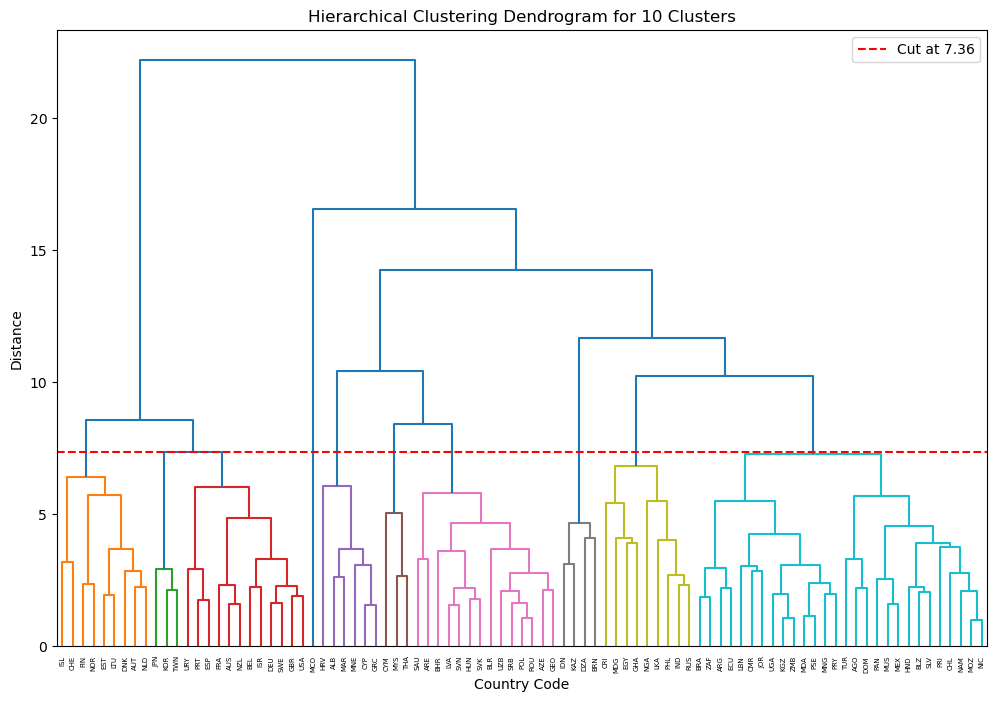

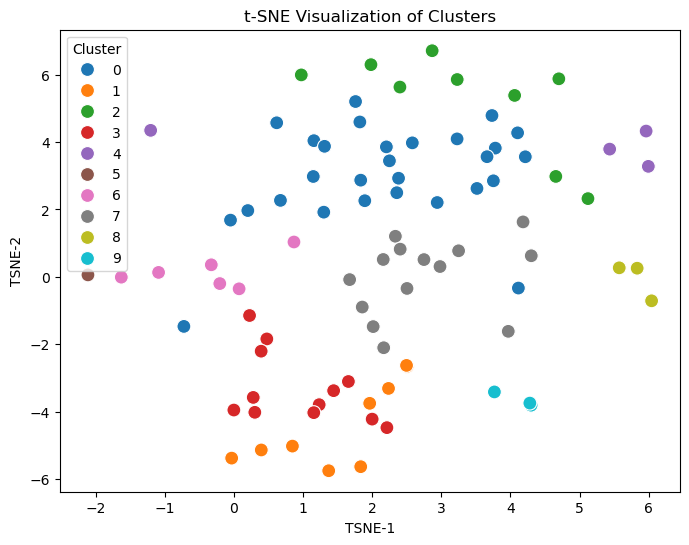

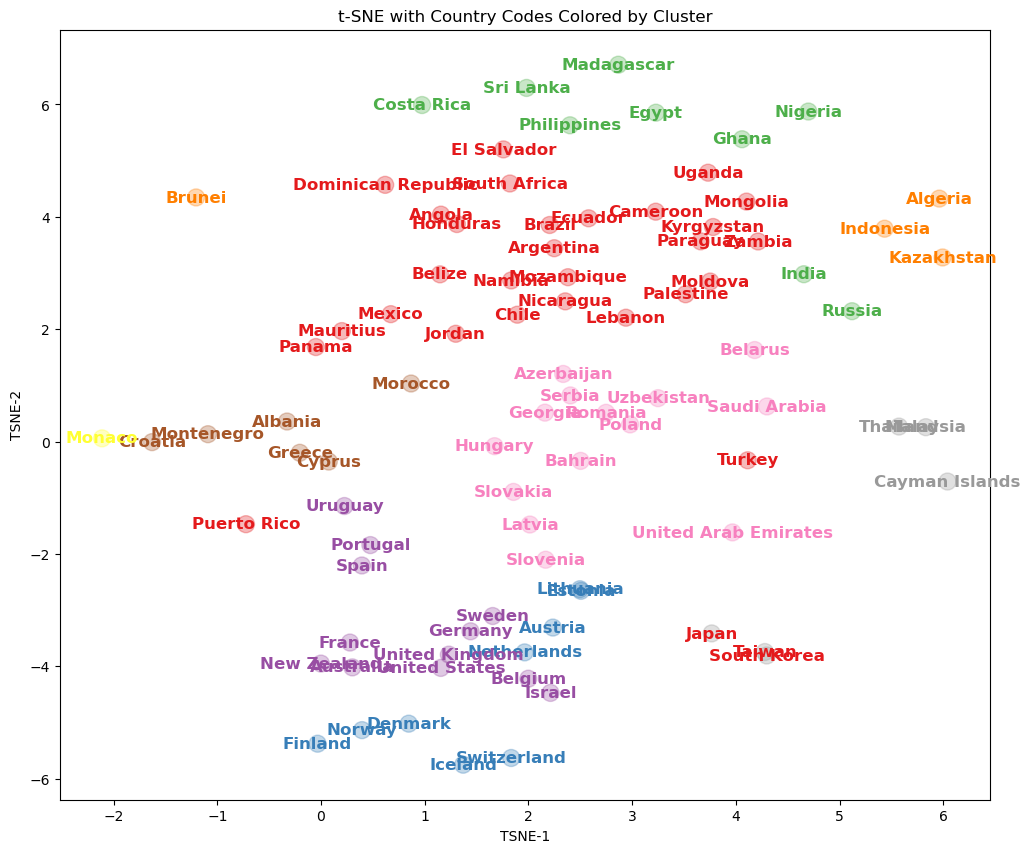

Validation Indices:
Davies-Bouldin Index: 1.3686682777175654
Calinski-Harabasz Index: 13.733544270799749
Dunn Index: 0.2913486719318367
Cluster mapping:
Cluster 0: Angola, Argentina, Belize, Brazil, Cameroon, Chile, Dominican Republic, Ecuador, El Salvador, Honduras, Jordan, Kyrgyzstan, Lebanon, Mauritius, Mexico, Moldova, Mongolia, Mozambique, Namibia, Nicaragua, Palestine, Panama, Paraguay, Puerto Rico, South Africa, Turkey, Uganda, Zambia
Cluster 1: Austria, Denmark, Estonia, Finland, Iceland, Lithuania, Netherlands, Norway, Switzerland
Cluster 2: Costa Rica, Egypt, Ghana, India, Madagascar, Nigeria, Philippines, Russia, Sri Lanka
Cluster 3: Australia, Belgium, France, Germany, Israel, New Zealand, Portugal, Spain, Sweden, United Kingdom, United States, Uruguay
Cluster 4: Algeria, Brunei, Indonesia, Kazakhstan
Cluster 5: Monaco
Cluster 6: Albania, Croatia, Cyprus, Greece, Montenegro, Morocco
Cluster 7: Azerbaijan, Bahrain, Belarus, Georgia, Hungary, Latvia, Poland, Romania, Saudi Ar

In [25]:
k_opt = 10
# Perform hierarchical clustering on the selected features using a chosen k
df_combined, cluster_labels, hierarchical_indices = utils.run_clustering_analysis(
    numerical_features_feature_selection_df,
    countries=labels_df,
    k_clusters=k_opt,
    plot_dendrogram_flag=True,
    plot_tsne_flag=True,
    compute_validation=True
)

In [26]:
# Hierarchical Clustering results
hierarchical_row = pd.DataFrame([{
    "Dataset": "Optimized Dataset",
    "Algorithm": "Hierarchical Clustering",
    "Davies-Bouldin Index": hierarchical_indices["Davies-Bouldin Index"],
    "Calinski-Harabasz Index": hierarchical_indices["Calinski-Harabasz Index"],
    "Dunn Index": hierarchical_indices["Dunn Index"]
}])

# Append Hierarchical Clustering row
results_df = pd.concat([results_df, hierarchical_row], ignore_index=True)

results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433
1,Baseline Dataset,Hierarchical Clustering,1.245876,18.026237,0.250485
2,Optimized Dataset,K-means,1.336015,22.109650,0.178352
3,Optimized Dataset,Hierarchical Clustering,1.368668,13.733544,0.291349


# Final result comparison
- **Davies-Bouldin Index** (lower is better)
- **Calinski-Harabasz Index** (higher is better)
- **Dunn Index** (higher is better)

In [27]:
results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433
1,Baseline Dataset,Hierarchical Clustering,1.245876,18.026237,0.250485
2,Optimized Dataset,K-means,1.336015,22.109650,0.178352
3,Optimized Dataset,Hierarchical Clustering,1.368668,13.733544,0.291349
